## Cài đặt thư viện và Tải ảnh

Chúng ta sẽ sử dụng `opencv-python` (cv2) để xử lý ảnh, `matplotlib` để hiển thị và `numpy` để thao tác với mảng ảnh.

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# Hàm để hiển thị ảnh
def show_image(title, image, figsize=(10, 8)):
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

def save_image(image, filename):
    output_dir = "./output"
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, filename)
    if not cv2.imwrite(output_path, image):
        raise IOError(f"Không thể lưu ảnh: {output_path}")
    print(f"Đã lưu ảnh: {output_path}")
    return output_path

print("Đã nhập các thư viện cần thiết.")

Đã nhập các thư viện cần thiết.


### Đọc ảnh đầu vào

Ảnh được đọc trực tiếp từ thư mục `./input/`: `image.png` (ảnh chính, được dùng xuyên suốt các đoạn code phía dưới) và `image_2.png` (ảnh phụ, dự phòng nếu cần).

Đã đọc ảnh 1: ./input/image.jpg, kích thước: (452, 678, 3)
Đã đọc ảnh 2: ./input/image_2.jpg, kích thước: (1390, 867, 3)


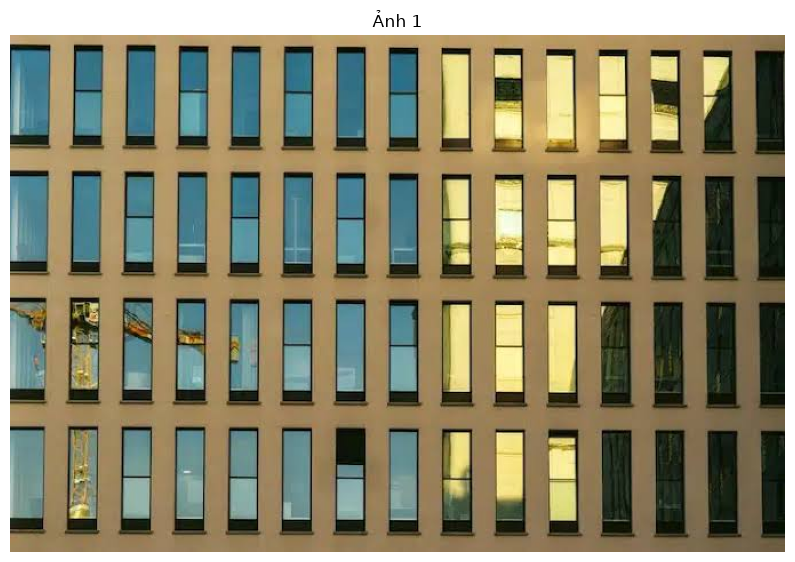

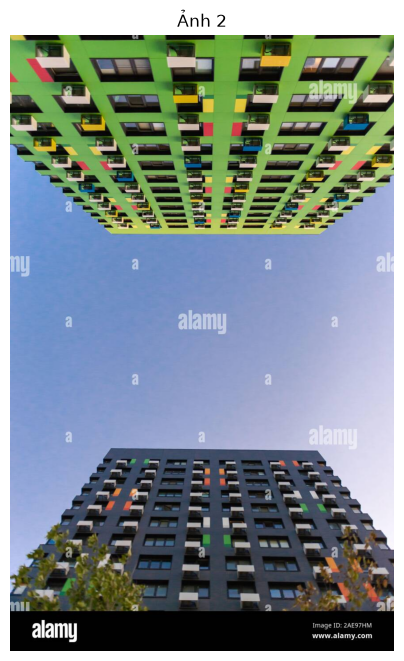

In [12]:
image_path_1 = "./input/image.jpg"
image_path_2 = "./input/image_2.jpg"
# Đọc cả hai ảnh từ thư mục input
original_image = cv2.imread(image_path_1, cv2.IMREAD_COLOR)
original_image_2 = cv2.imread(image_path_2, cv2.IMREAD_COLOR)

if original_image is None:
    raise FileNotFoundError(f"Không thể đọc ảnh: {image_path_1}")
if original_image_2 is None:
    raise FileNotFoundError(f"Không thể đọc ảnh: {image_path_2}")

print(f"Đã đọc ảnh 1: {image_path_1}, kích thước: {original_image.shape}")
print(f"Đã đọc ảnh 2: {image_path_2}, kích thước: {original_image_2.shape}")

show_image("Ảnh 1", original_image)
show_image("Ảnh 2", original_image_2)

## 1. Biến đổi Tịnh tiến (Translation)

Tịnh tiến là việc di chuyển ảnh theo một hướng nhất định (ngang, dọc) mà không thay đổi kích thước hay hình dạng của ảnh. Ma trận biến đổi tịnh tiến được định nghĩa là:

$$M = \begin{bmatrix} 1 & 0 & t_x \\ 0 & 1 & t_y \end{bmatrix}$$

Trong đó $t_x$ là số pixel di chuyển theo trục x và $t_y$ là số pixel di chuyển theo trục y.

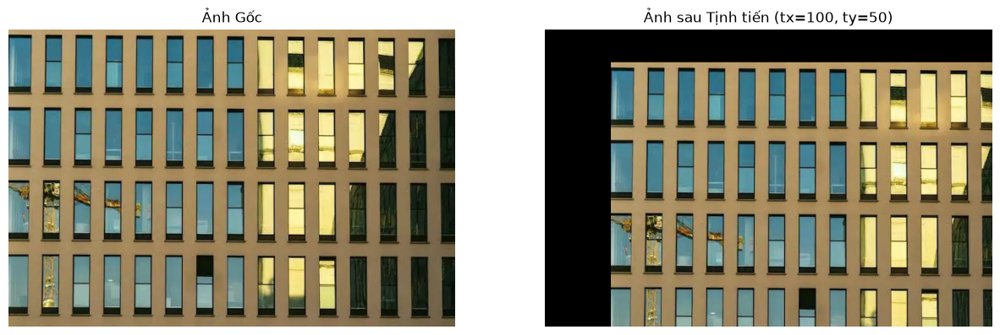

Đã lưu ảnh: ./output\translated.jpg
Nhận xét: Ảnh đã được di chuyển 100 pixel sang phải và 50 pixel xuống dưới. Kích thước và hình dạng của đối tượng không thay đổi.


In [13]:
if 'original_image' in locals():
    rows, cols = original_image.shape[:2]

    # Thiết lập tham số tịnh tiến
    tx = 100 # Di chuyển 100 pixel sang phải
    ty = 50  # Di chuyển 50 pixel xuống dưới

    # Tạo ma trận tịnh tiến
    M_translate = np.float32([[1, 0, tx], [0, 1, ty]])

    # Áp dụng biến đổi tịnh tiến
    translated_image = cv2.warpAffine(original_image, M_translate, (cols, rows))

    # Hiển thị ảnh gốc và ảnh sau khi tịnh tiến
    plt.figure(figsize=(15, 7))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
    plt.title('Ảnh Gốc')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(translated_image, cv2.COLOR_BGR2RGB))
    plt.title(f'Ảnh sau Tịnh tiến (tx={tx}, ty={ty})')
    plt.axis('off')
    plt.show()

    save_image(translated_image, "translated.jpg")
    print(f"Nhận xét: Ảnh đã được di chuyển {tx} pixel sang phải và {ty} pixel xuống dưới. Kích thước và hình dạng của đối tượng không thay đổi.")
else:
    print("Không có ảnh gốc để thực hiện tịnh tiến.")

## 2. Biến đổi Tỉ lệ (Scaling)

Biến đổi tỉ lệ là việc thay đổi kích thước của ảnh. Ảnh có thể được phóng to hoặc thu nhỏ. Ma trận biến đổi tỉ lệ được định nghĩa là:

$$M = \begin{bmatrix} s_x & 0 & 0 \\ 0 & s_y & 0 \end{bmatrix}$$

Trong đó $s_x$ là hệ số tỉ lệ theo trục x và $s_y$ là hệ số tỉ lệ theo trục y. Lưu ý rằng `cv2.warpAffine` yêu cầu một ma trận 2x3, và tham số kích thước đầu ra (`dsize`) là rất quan trọng.

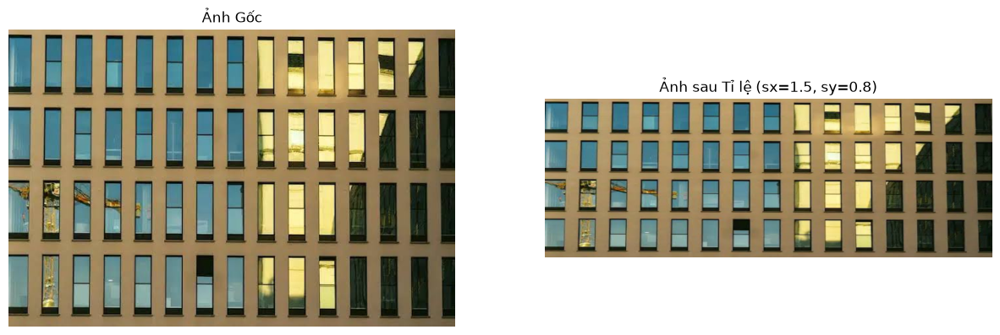

Đã lưu ảnh: ./output\scaled.jpg
Nhận xét: Ảnh đã được phóng to 1.5 lần theo chiều rộng và thu nhỏ 0.8 lần theo chiều cao. Hình dạng đối tượng không bị biến dạng, chỉ có kích thước thay đổi. Kích thước ảnh mới là (361, 1017).


In [14]:
if 'original_image' in locals():
    rows, cols = original_image.shape[:2]

    # Thiết lập hệ số tỉ lệ
    sx = 1.5 # Phóng to 1.5 lần theo chiều rộng
    sy = 0.8 # Thu nhỏ 0.8 lần theo chiều cao

    # Kích thước ảnh mới
    new_cols = int(cols * sx)
    new_rows = int(rows * sy)

    # Áp dụng biến đổi tỉ lệ sử dụng cv2.resize để đơn giản
    # Hoặc có thể dùng ma trận và cv2.warpAffine nếu muốn kết hợp với các biến đổi khác
    scaled_image = cv2.resize(original_image, (new_cols, new_rows), interpolation=cv2.INTER_LINEAR)

    # Hiển thị ảnh gốc và ảnh sau khi tỉ lệ
    plt.figure(figsize=(15, 7))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
    plt.title('Ảnh Gốc')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(scaled_image, cv2.COLOR_BGR2RGB))
    plt.title(f'Ảnh sau Tỉ lệ (sx={sx}, sy={sy})')
    plt.axis('off')
    plt.show()

    save_image(scaled_image, "scaled.jpg")
    print(f"Nhận xét: Ảnh đã được phóng to {sx} lần theo chiều rộng và thu nhỏ {sy} lần theo chiều cao. Hình dạng đối tượng không bị biến dạng, chỉ có kích thước thay đổi. Kích thước ảnh mới là ({new_rows}, {new_cols}).")
else:
    print("Không có ảnh gốc để thực hiện tỉ lệ.")

## 3. Biến đổi Cắt xén (Shearing)

Biến đổi cắt xén làm nghiêng hoặc biến dạng ảnh theo một trục nhất định. Có thể là cắt xén theo chiều ngang (x) hoặc chiều dọc (y).

Ma trận biến đổi cắt xén theo trục x (giữ y cố định, x thay đổi):

$$M = \begin{bmatrix} 1 & s_x & 0 \\ 0 & 1 & 0 \end{bmatrix}$$

Ma trận biến đổi cắt xén theo trục y (giữ x cố định, y thay đổi):

$$M = \begin{bmatrix} 1 & 0 & 0 \\ s_y & 1 & 0 \end{bmatrix}$$

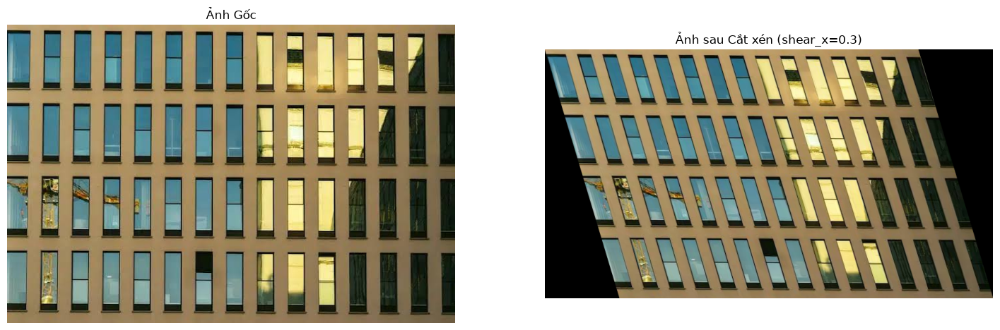

Đã lưu ảnh: ./output\sheared.jpg
Nhận xét: Ảnh đã được cắt xén theo chiều ngang với hệ số 0.3, làm cho các cạnh dọc bị nghiêng. Hình dạng của đối tượng bị biến dạng nhưng các đường thẳng vẫn là đường thẳng.


In [15]:
if 'original_image' in locals():
    rows, cols = original_image.shape[:2]

    # Thiết lập hệ số cắt xén (shear factor)
    shear_factor_x = 0.3 # Cắt xén theo trục x
    # shear_factor_y = 0.2 # Cắt xén theo trục y (ví dụ)

    # Ma trận cắt xén theo trục x
    M_shear_x = np.float32([
        [1, shear_factor_x, 0],
        [0, 1, 0]
    ])

    # Áp dụng biến đổi cắt xén
    # Kích thước đầu ra cần được điều chỉnh để chứa toàn bộ ảnh bị cắt xén
    # Tính toán kích thước mới để tránh cắt bớt ảnh
    new_width_shear = int(cols + abs(shear_factor_x * rows))
    new_height_shear = rows # Chiều cao không đổi khi cắt xén theo trục X

    sheared_image = cv2.warpAffine(original_image, M_shear_x, (new_width_shear, new_height_shear))

    # Hiển thị ảnh gốc và ảnh sau khi cắt xén
    plt.figure(figsize=(18, 7))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
    plt.title('Ảnh Gốc')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(sheared_image, cv2.COLOR_BGR2RGB))
    plt.title(f'Ảnh sau Cắt xén (shear_x={shear_factor_x})')
    plt.axis('off')
    plt.show()

    save_image(sheared_image, "sheared.jpg")
    print(f"Nhận xét: Ảnh đã được cắt xén theo chiều ngang với hệ số {shear_factor_x}, làm cho các cạnh dọc bị nghiêng. Hình dạng của đối tượng bị biến dạng nhưng các đường thẳng vẫn là đường thẳng.")
else:
    print("Không có ảnh gốc để thực hiện cắt xén.")

## 4. Biến đổi Xoay (Rotation)

Biến đổi xoay là việc quay ảnh quanh một điểm trung tâm với một góc nhất định. Ma trận biến đổi xoay được định nghĩa là:

$$M = \begin{bmatrix} \cos\theta & -\sin\theta & (1-\cos\theta)c_x + (\sin\theta)c_y \\ \sin\theta & \cos\theta & -(\sin\theta)c_x + (1-\cos\theta)c_y \end{bmatrix}$$

Trong đó $\theta$ là góc xoay, và $(c_x, c_y)$ là điểm trung tâm xoay. `cv2.getRotationMatrix2D` giúp tạo ma trận này dễ dàng.

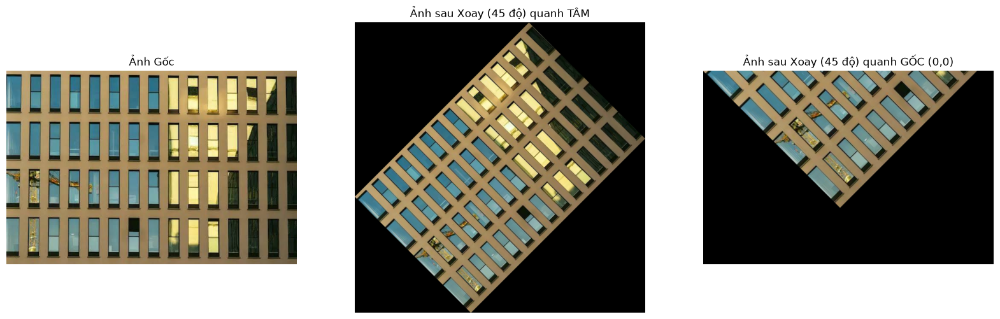

Đã lưu ảnh: ./output\rotated_around_center.jpg
Đã lưu ảnh: ./output\rotated_around_origin.jpg
Nhận xét: Ảnh đã được xoay 45 độ. Khi xoay quanh tâm ảnh, toàn bộ đối tượng xoay tại chỗ và ảnh đầu ra được điều chỉnh kích thước để chứa toàn bộ. Khi xoay quanh gốc tọa độ (0,0), đối tượng sẽ xoay xung quanh điểm này, dẫn đến việc ảnh có thể bị dịch chuyển ra khỏi khung nhìn hoặc bị cắt bớt nếu không điều chỉnh kích thước đầu ra phù hợp. Điều này làm nổi bật tầm quan trọng của việc chọn đúng tâm xoay.


In [16]:
if 'original_image' in locals():
    rows, cols = original_image.shape[:2]

    angle = 45 # Góc xoay 45 độ
    scale = 1.0 # Tỉ lệ sau khi xoay (giữ nguyên kích thước)

    # --- Xoay quanh TÂM ảnh ---
    center_image = (cols // 2, rows // 2) # Trung tâm ảnh
    M_rotate_center = cv2.getRotationMatrix2D(center_image, angle, scale)

    # Tính toán kích thước ảnh đầu ra mới để tránh cắt bớt ảnh (cho xoay quanh tâm)
    abs_cos_center = abs(M_rotate_center[0,0])
    abs_sin_center = abs(M_rotate_center[0,1])
    bound_w_center = int(rows * abs_sin_center + cols * abs_cos_center)
    bound_h_center = int(rows * abs_cos_center + cols * abs_sin_center)

    # Điều chỉnh ma trận để dịch chuyển tâm xoay đến giữa khung ảnh mới
    M_rotate_center[0, 2] += bound_w_center / 2 - center_image[0]
    M_rotate_center[1, 2] += bound_h_center / 2 - center_image[1]

    rotated_around_center_image = cv2.warpAffine(original_image, M_rotate_center, (bound_w_center, bound_h_center))

    # --- Xoay quanh GỐC tọa độ (0,0) ---
    center_origin = (0, 0) # Gốc tọa độ (0,0)
    M_rotate_origin = cv2.getRotationMatrix2D(center_origin, angle, scale)

    # Khi xoay quanh gốc, ảnh có thể dịch chuyển đáng kể, cần tính toán lại kích thước
    # và dịch chuyển để không bị cắt xén nếu muốn hiển thị toàn bộ
    # Tuy nhiên, để minh họa rõ tác động của tâm xoay, chúng ta sẽ giữ kích thước cũ
    # và chấp nhận việc một phần ảnh có thể bị cắt (hoặc dịch chuyển ra ngoài khung)
    # Nếu muốn hiển thị toàn bộ, cần tính toán bounding box mới tương tự như trên.
    # Để đơn giản và làm nổi bật sự khác biệt của tâm xoay, ta dùng kích thước gốc.
    rotated_around_origin_image = cv2.warpAffine(original_image, M_rotate_origin, (cols, rows))

    # Hiển thị ảnh gốc và ảnh sau khi xoay
    plt.figure(figsize=(20, 7))
    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
    plt.title('Ảnh Gốc')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(cv2.cvtColor(rotated_around_center_image, cv2.COLOR_BGR2RGB))
    plt.title(f'Ảnh sau Xoay ({angle} độ) quanh TÂM')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(rotated_around_origin_image, cv2.COLOR_BGR2RGB))
    plt.title(f'Ảnh sau Xoay ({angle} độ) quanh GỐC (0,0)')
    plt.axis('off')
    plt.show()

    rotate_center_path = save_image(rotated_around_center_image, "rotated_around_center.jpg")
    rotate_origin_path = save_image(rotated_around_origin_image, "rotated_around_origin.jpg")
    print(f"Nhận xét: Ảnh đã được xoay {angle} độ. Khi xoay quanh tâm ảnh, toàn bộ đối tượng xoay tại chỗ và ảnh đầu ra được điều chỉnh kích thước để chứa toàn bộ. Khi xoay quanh gốc tọa độ (0,0), đối tượng sẽ xoay xung quanh điểm này, dẫn đến việc ảnh có thể bị dịch chuyển ra khỏi khung nhìn hoặc bị cắt bớt nếu không điều chỉnh kích thước đầu ra phù hợp. Điều này làm nổi bật tầm quan trọng của việc chọn đúng tâm xoay.")
else:
    print("Không có ảnh gốc để thực hiện xoay.")

## 5. Biến đổi Affine (Affine Transformation)

Biến đổi Affine là một biến đổi tuyến tính bảo toàn các đường thẳng và tính song song nhưng không nhất thiết phải bảo toàn góc và chiều dài. Nó có thể được xem là sự kết hợp của tịnh tiến, tỉ lệ, xoay và cắt xén. Để xác định một biến đổi Affine, chúng ta cần 3 cặp điểm tương ứng (trước và sau biến đổi).

Ma trận biến đổi Affine là một ma trận 2x3.

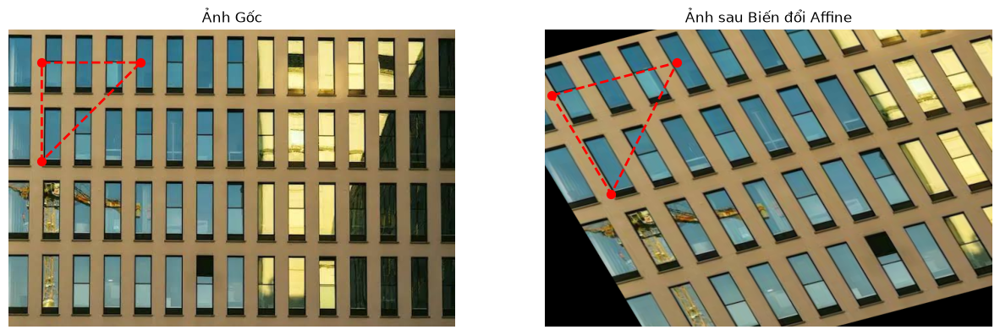

Đã lưu ảnh: ./output\affine_transformed.jpg
Nhận xét: Ảnh đã trải qua một biến đổi Affine, kết hợp các hiệu ứng tịnh tiến, xoay, tỉ lệ và cắt xén. Các đường thẳng vẫn song song với nhau.


In [17]:
if 'original_image' in locals():
    rows, cols = original_image.shape[:2]

    # 3 điểm gốc trên ảnh
    pts1 = np.float32([[50, 50], [200, 50], [50, 200]])
    # 3 điểm đích tương ứng
    pts2 = np.float32([[10, 100], [200, 50], [100, 250]])

    # Lấy ma trận biến đổi affine
    M_affine = cv2.getAffineTransform(pts1, pts2)

    # Áp dụng biến đổi affine
    affine_transformed_image = cv2.warpAffine(original_image, M_affine, (cols, rows))

    # Hiển thị ảnh gốc và ảnh sau biến đổi Affine
    plt.figure(figsize=(15, 7))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
    plt.title('Ảnh Gốc')
    plt.axis('off')
    # Thêm overlay cho ảnh gốc
    plt.scatter(pts1[:, 0], pts1[:, 1], color='red', s=50, marker='o')
    plt.plot(pts1[[0,1,2,0],0], pts1[[0,1,2,0],1], color='red', linestyle='--', linewidth=2)

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(affine_transformed_image, cv2.COLOR_BGR2RGB))
    plt.title('Ảnh sau Biến đổi Affine')
    plt.axis('off')
    # Thêm overlay cho ảnh đã biến đổi
    plt.scatter(pts2[:, 0], pts2[:, 1], color='red', s=50, marker='o')
    plt.plot(pts2[[0,1,2,0],0], pts2[[0,1,2,0],1], color='red', linestyle='--', linewidth=2)
    plt.show()

    save_image(affine_transformed_image, "affine_transformed.jpg")
    print("Nhận xét: Ảnh đã trải qua một biến đổi Affine, kết hợp các hiệu ứng tịnh tiến, xoay, tỉ lệ và cắt xén. Các đường thẳng vẫn song song với nhau.")
else:
    print("Không có ảnh gốc để thực hiện biến đổi Affine.")

### Ảnh hưởng của thứ tự Composition trong Biến đổi Affine

Thứ tự áp dụng các biến đổi (như xoay, tịnh tiến, tỉ lệ) trong biến đổi Affine có thể ảnh hưởng đáng kể đến kết quả cuối cùng. Điều này là do các phép biến đổi này không có tính giao hoán. Dưới đây là ví dụ minh họa sự khác biệt khi áp dụng xoay và tịnh tiến theo hai thứ tự khác nhau.

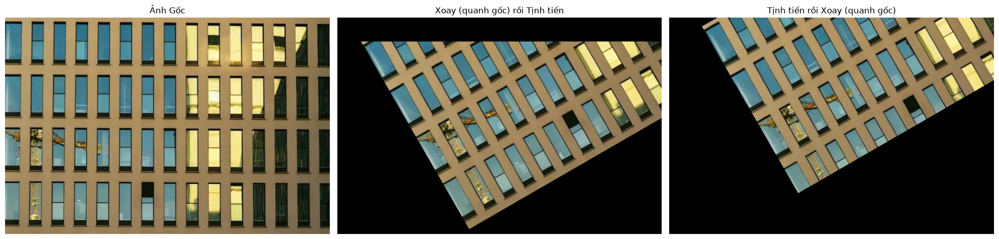

Nhận xét: Khi xoay quanh gốc tọa độ (0,0), thứ tự của các phép biến đổi (xoay và tịnh tiến) ảnh hưởng rất rõ ràng đến kết quả cuối cùng. Điều này là do mỗi phép biến đổi thay đổi hệ tọa độ của ảnh, và phép biến đổi tiếp theo sẽ được áp dụng trên hệ tọa độ mới đó. Nếu xoay quanh tâm ảnh, sự khác biệt sẽ ít rõ ràng hơn.


In [18]:
if 'original_image' in locals():
    rows, cols = original_image.shape[:2]

    # Tham số tịnh tiến
    tx_comp = 50 # Di chuyển 50 pixel sang phải
    ty_comp = 50 # Di chuyển 20 pixel xuống dưới
    M_translate_comp = np.float32([[1, 0, tx_comp], [0, 1, ty_comp]])

    # Tham số cho xoay quanh GỐC tọa độ (0,0)
    angle_comp = 30 # Xoay 30 độ
    center_origin = (0, 0) # Xoay quanh gốc tọa độ (0,0)
    scale_comp = 1.0
    M_rotate_origin_comp = cv2.getRotationMatrix2D(center_origin, angle_comp, scale_comp)

    # --- Trường hợp 1: Xoay (quanh gốc) trước, sau đó Tịnh tiến ---
    rotated_then_translated = cv2.warpAffine(original_image, M_rotate_origin_comp, (cols, rows))
    rotated_then_translated = cv2.warpAffine(rotated_then_translated, M_translate_comp, (cols, rows))

    # --- Trường hợp 2: Tịnh tiến trước, sau đó Xoay (quanh gốc) ---
    translated_then_rotated = cv2.warpAffine(original_image, M_translate_comp, (cols, rows))
    translated_then_rotated = cv2.warpAffine(translated_then_rotated, M_rotate_origin_comp, (cols, rows))

    # Hiển thị kết quả
    plt.figure(figsize=(20, 10))
    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
    plt.title('Ảnh Gốc')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(cv2.cvtColor(rotated_then_translated, cv2.COLOR_BGR2RGB))
    plt.title('Xoay (quanh gốc) rồi Tịnh tiến')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(translated_then_rotated, cv2.COLOR_BGR2RGB))
    plt.title('Tịnh tiến rồi Xoay (quanh gốc)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    print("Nhận xét: Khi xoay quanh gốc tọa độ (0,0), thứ tự của các phép biến đổi (xoay và tịnh tiến) ảnh hưởng rất rõ ràng đến kết quả cuối cùng. Điều này là do mỗi phép biến đổi thay đổi hệ tọa độ của ảnh, và phép biến đổi tiếp theo sẽ được áp dụng trên hệ tọa độ mới đó. Nếu xoay quanh tâm ảnh, sự khác biệt sẽ ít rõ ràng hơn.")
else:
    print("Không có ảnh gốc để thực hiện biến đổi affine composition.")

## 6. Biến đổi Phép chiếu (Perspective Transformation)

Biến đổi phép chiếu (còn gọi là biến đổi phối cảnh) là một biến đổi phi tuyến tính, mạnh mẽ hơn biến đổi Affine. Nó không chỉ biến đổi hình dạng mà còn thay đổi góc nhìn của ảnh, làm cho các đường song song có thể không còn song song sau biến đổi. Để xác định một biến đổi phép chiếu, chúng ta cần 4 cặp điểm tương ứng.

Ma trận biến đổi phép chiếu là một ma trận 3x3.

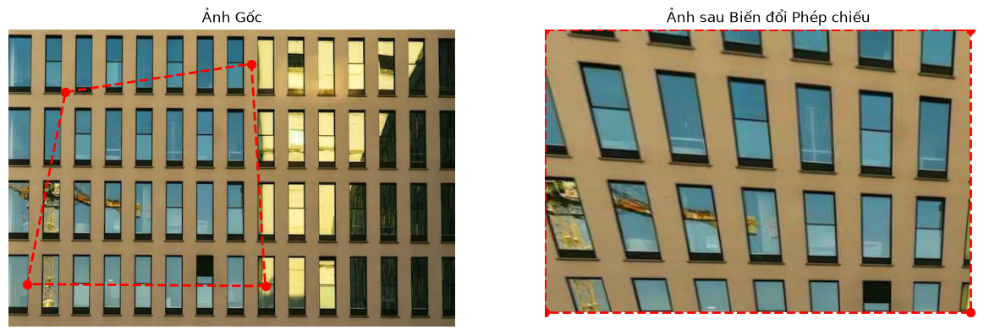

Đã lưu ảnh: ./output\perspective_transformed.jpg
Nhận xét: Ảnh đã trải qua biến đổi phép chiếu. Biến đổi này có thể tạo ra hiệu ứng phối cảnh, làm cho ảnh trông như được nhìn từ một góc độ khác. Các đường song song có thể không còn song song nữa.


In [19]:
if 'original_image' in locals():
    rows, cols = original_image.shape[:2]

    # 4 điểm gốc trên ảnh (ví dụ: các góc của một hình chữ nhật)
    pts1_perspective = np.float32([[86, 95], [368, 52], [28, 387], [389, 390]])
    # 4 điểm đích tương ứng (biến đổi thành một hình chữ nhật mới)
    pts2_perspective = np.float32([[0, 0], [cols, 0], [0, rows], [cols, rows]])

    # Lấy ma trận biến đổi phép chiếu
    M_perspective = cv2.getPerspectiveTransform(pts1_perspective, pts2_perspective)

    # Áp dụng biến đổi phép chiếu
    perspective_transformed_image = cv2.warpPerspective(original_image, M_perspective, (cols, rows))

    # Hiển thị ảnh gốc và ảnh sau biến đổi phép chiếu
    plt.figure(figsize=(15, 7))
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB))
    plt.title('Ảnh Gốc')
    plt.axis('off')
    # Thêm overlay cho ảnh gốc
    plt.scatter(pts1_perspective[:, 0], pts1_perspective[:, 1], color='red', s=50, marker='o')
    plt.plot(pts1_perspective[[0,1,3,2,0],0], pts1_perspective[[0,1,3,2,0],1], color='red', linestyle='--', linewidth=2)

    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(perspective_transformed_image, cv2.COLOR_BGR2RGB))
    plt.title('Ảnh sau Biến đổi Phép chiếu')
    plt.axis('off')
    # Thêm overlay cho ảnh đã biến đổi
    plt.scatter(pts2_perspective[:, 0], pts2_perspective[:, 1], color='red', s=50, marker='o')
    plt.plot(pts2_perspective[[0,1,3,2,0],0], pts2_perspective[[0,1,3,2,0],1], color='red', linestyle='--', linewidth=2)
    plt.show()

    save_image(perspective_transformed_image, "perspective_transformed.jpg")
    print("Nhận xét: Ảnh đã trải qua biến đổi phép chiếu. Biến đổi này có thể tạo ra hiệu ứng phối cảnh, làm cho ảnh trông như được nhìn từ một góc độ khác. Các đường song song có thể không còn song song nữa.")
else:
    print("Không có ảnh gốc để thực hiện biến đổi phép chiếu.")

### Ảnh hưởng của Hệ số 'w' trong Biến đổi Phép chiếu

Trong biểu diễn tọa độ đồng nhất (homogeneous coordinates) $[x, y, w]$ được sử dụng trong biến đổi phép chiếu, hệ số $w$ đóng vai trò quan trọng. Khi thực hiện biến đổi, các điểm được chuyển về dạng 3D $[x', y', w']$, sau đó được chuẩn hóa về mặt phẳng 2D bằng cách chia cho $w'$ để có tọa độ $(x'/w', y'/w')$. Thay đổi các giá trị ở hàng cuối cùng của ma trận phép chiếu (liên quan đến $w$) sẽ ảnh hưởng đến cách các điểm được chiếu và do đó thay đổi góc nhìn và sự biến dạng phối cảnh của ảnh.

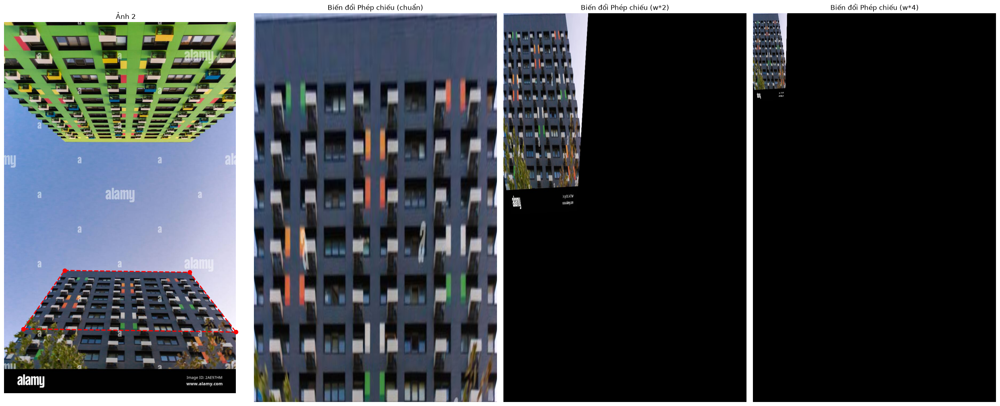

Nhận xét: Khi chúng ta thay đổi các thành phần của hàng cuối cùng của ma trận phép chiếu (liên quan đến hệ số 'w'), ảnh sau biến đổi có sự biến dạng phối cảnh khác biệt đáng kể. Giá trị của G và H càng lớn, hiệu ứng phối cảnh càng mạnh, làm cho ảnh bị "kéo dãn" hoặc "thu hẹp" mạnh hơn ở các vùng tương ứng. Điều này cho thấy hệ số 'w' kiểm soát 'độ sâu' hoặc 'góc nhìn' của biến đổi phép chiếu.


In [20]:
if original_image_2 is not None:
    rows_2, cols_2 = original_image_2.shape[:2]

    # 4 điểm gốc trên ảnh thứ hai
    pts1_w = np.float32([[226, 930], [693, 937], [72, 1149], [867, 1161]])
    # 4 điểm đích tương ứng
    pts2_w = np.float32([[0, 0], [cols_2, 0], [0, rows_2], [cols_2, rows_2]])

    # Lấy ma trận biến đổi phép chiếu chuẩn
    M_perspective_standard = cv2.getPerspectiveTransform(pts1_w, pts2_w)

    # Áp dụng biến đổi phép chiếu chuẩn lên ảnh thứ hai
    perspective_standard_image = cv2.warpPerspective(original_image_2, M_perspective_standard, (cols_2, rows_2))

    # --- Thử nghiệm 1: Tăng độ 'phối cảnh' bằng cách nhân M[2,0] và M[2,1] với 2 ---
    M_perspective_modified_w_1 = M_perspective_standard.copy()
    M_perspective_modified_w_1[2, 0] = M_perspective_standard[2, 0] * 2  # Tăng hiệu ứng phối cảnh theo x
    M_perspective_modified_w_1[2, 1] = M_perspective_standard[2, 1] * 2  # Tăng hiệu ứng phối cảnh theo y

    perspective_modified_w_image_1 = cv2.warpPerspective(original_image_2, M_perspective_modified_w_1, (cols_2, rows_2))

    # --- Thử nghiệm 2: Tăng độ 'phối cảnh' mạnh hơn bằng cách nhân M[2,0] và M[2,1] với 4 ---
    M_perspective_modified_w_2 = M_perspective_standard.copy()
    M_perspective_modified_w_2[2, 0] = M_perspective_standard[2, 0] * 4  # Tăng hiệu ứng phối cảnh theo x mạnh hơn
    M_perspective_modified_w_2[2, 1] = M_perspective_standard[2, 1] * 4  # Tăng hiệu ứng phối cảnh theo y mạnh hơn

    perspective_modified_w_image_2 = cv2.warpPerspective(original_image_2, M_perspective_modified_w_2, (cols_2, rows_2))

    # Hiển thị kết quả
    plt.figure(figsize=(25, 10))
    plt.subplot(1, 4, 1)
    plt.imshow(cv2.cvtColor(original_image_2, cv2.COLOR_BGR2RGB))
    plt.title('Ảnh 2')
    plt.axis('off')
    plt.scatter(pts1_w[:, 0], pts1_w[:, 1], color='red', s=50, marker='o')
    plt.plot(pts1_w[[0,1,3,2,0],0], pts1_w[[0,1,3,2,0],1], color='red', linestyle='--', linewidth=2)

    plt.subplot(1, 4, 2)
    plt.imshow(cv2.cvtColor(perspective_standard_image, cv2.COLOR_BGR2RGB))
    plt.title('Biến đổi Phép chiếu (chuẩn)')
    plt.axis('off')

    plt.subplot(1, 4, 3)
    plt.imshow(cv2.cvtColor(perspective_modified_w_image_1, cv2.COLOR_BGR2RGB))
    plt.title('Biến đổi Phép chiếu (w*2)')
    plt.axis('off')

    plt.subplot(1, 4, 4)
    plt.imshow(cv2.cvtColor(perspective_modified_w_image_2, cv2.COLOR_BGR2RGB))
    plt.title('Biến đổi Phép chiếu (w*4)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    print("Nhận xét: Khi chúng ta thay đổi các thành phần của hàng cuối cùng của ma trận phép chiếu (liên quan đến hệ số 'w'), ảnh sau biến đổi có sự biến dạng phối cảnh khác biệt đáng kể. Giá trị của G và H càng lớn, hiệu ứng phối cảnh càng mạnh, làm cho ảnh bị \"kéo dãn\" hoặc \"thu hẹp\" mạnh hơn ở các vùng tương ứng. Điều này cho thấy hệ số 'w' kiểm soát 'độ sâu' hoặc 'góc nhìn' của biến đổi phép chiếu.")
else:
    print("Không có ảnh thứ hai để thực hiện biến đổi phép chiếu với hệ số 'w'.")

## 7. Hiển thị Tổng quan tất cả các biến đổi

Phần này sẽ hiển thị tất cả các ảnh: ảnh gốc, ảnh đã tịnh tiến, tỉ lệ, cắt xén, xoay, biến đổi affine và biến đổi phép chiếu để có cái nhìn tổng thể về các phép biến đổi hình học.

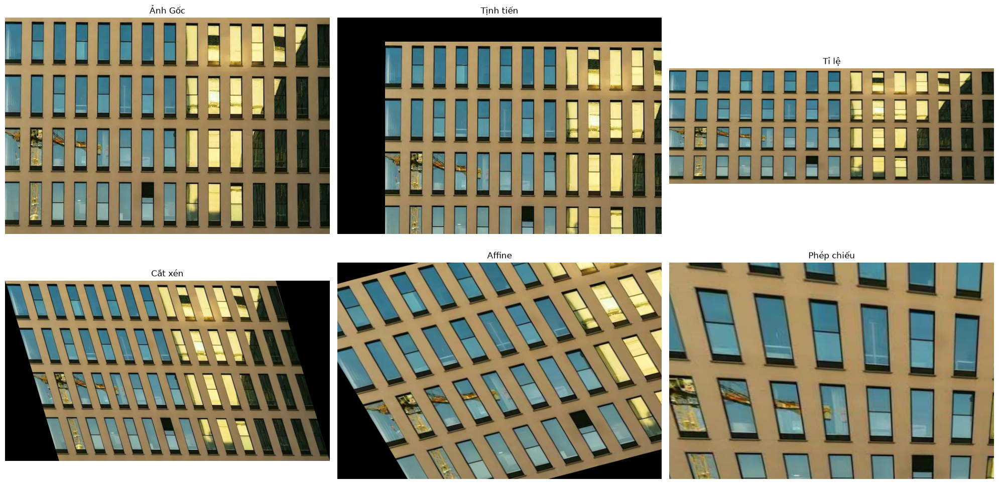

Nhận xét tổng quan: Mỗi phép biến đổi hình học tác động đến ảnh theo một cách riêng biệt, làm thay đổi vị trí, kích thước, hình dạng hoặc góc nhìn của đối tượng trong ảnh. Sự kết hợp của các biến đổi này cho phép chúng ta thực hiện các thao tác phức tạp hơn trên ảnh.


In [21]:
plt.figure(figsize=(20, 15))

# Kiểm tra sự tồn tại của các biến đã được tạo ra trong các cell trước
images_to_show = {
    "Ảnh Gốc": original_image if 'original_image' in locals() else None,
    "Tịnh tiến": translated_image if 'translated_image' in locals() else None,
    "Tỉ lệ": scaled_image if 'scaled_image' in locals() else None,
    "Cắt xén": sheared_image if 'sheared_image' in locals() else None,
    "Xoay": rotated_image if 'rotated_image' in locals() else None,
    "Affine": affine_transformed_image if 'affine_transformed_image' in locals() else None,
    "Phép chiếu": perspective_transformed_image if 'perspective_transformed_image' in locals() else None
}

i = 1
for title, img in images_to_show.items():
    if img is not None:
        plt.subplot(3, 3, i) # 3 hàng, 3 cột
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis('off')
        i += 1

plt.tight_layout()
plt.show()

print("Nhận xét tổng quan: Mỗi phép biến đổi hình học tác động đến ảnh theo một cách riêng biệt, làm thay đổi vị trí, kích thước, hình dạng hoặc góc nhìn của đối tượng trong ảnh. Sự kết hợp của các biến đổi này cho phép chúng ta thực hiện các thao tác phức tạp hơn trên ảnh.")